In [1]:
!pip install scikit-learn pandas numpy

## Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load and Inspect the Dataset

In [3]:
# Load dataset (Replace with your actual file path or upload file in Colab)
from google.colab import files
uploaded = files.upload()  # Upload your CSV file

df = pd.read_csv("Menses_cleaned(1).csv")  # Update the filename if needed

# Display the first 5 rows of the dataset
df.head()

Saving Menses_cleaned(1).csv to Menses_cleaned(1).csv


,LengthofCycle,MeanCycleLength,LengthofMenses,MeanMensesLength,BMI
0,29,27.33,5.0,4.49,0.133817
1,33,33.38,5.0,4.77,0.536049
2,28,28.80,6.0,5.50,0.170323
3,31,31.33,7.0,5.67,0.347924
4,31,28.23,6.0,5.62,0.347924


## Define Features and Target Variable

In [4]:
# Define features (X) and target variable (y)
X = df.drop(columns=["LengthofCycle"])  # Drop target column to get features
y = df["LengthofCycle"]

# Display the shape of features and target variable
print(f"Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")

Feature matrix shape: (1665, 4)
Target variable shape: (1665,)


## Split Data into Training and Testing Sets

In [5]:
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shape of training and test sets
print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, {y_test.shape}")

Training data shape: (1332, 4), (1332,)
Testing data shape: (333, 4), (333,)


## Define Hyperparameter Grid for Random Forest

In [6]:
# Define hyperparameter grid for RandomForestRegressor
param_grid = {
    'n_estimators': [50, 100, 200],   # Number of trees
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the trees
    'min_samples_split': [2, 5, 10],  # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4],    # Minimum samples at a leaf node
    'max_features': ['sqrt', 'log2', None]  # Fixed: Removed 'auto'
}

# Display hyperparameter grid
print(param_grid)

{'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'max_features': ['sqrt', 'log2', None]}


## Train the Model Using GridSearchCV

In [7]:
# Initialize the Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)

# Apply GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid,
                           scoring='r2', cv=5, n_jobs=-1, verbose=2)

# Train the model
grid_search.fit(X_train, y_train)

# Print the best hyperparameters
print(f"Best Hyperparameters: {grid_search.best_params_}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Hyperparameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}


## Train Final Model Using Best Parameters

In [8]:
# Train the final model with best hyperparameters
best_rf = grid_search.best_estimator_

# Display the best model
print(best_rf)

RandomForestRegressor(max_depth=10, max_features='sqrt', min_samples_leaf=4,
                      min_samples_split=10, n_estimators=50, random_state=42)


## Make Predictions

In [9]:
# Make predictions
y_pred = best_rf.predict(X_test)

# Display first 10 predictions
predictions_df = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
predictions_df.head(10)

,Actual,Predicted
0,25,25.157008
1,38,32.276606
2,26,26.897428
3,23,27.632012
4,25,26.293933
5,25,26.860637
6,28,31.522650
7,37,31.252728
8,31,27.887888
9,24,27.977124


## Evaluate Model Performance

In [10]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared Score (R2): {r2}")

Mean Absolute Error (MAE): 2.062592501450798
Mean Squared Error (MSE): 8.657576277256181
Root Mean Squared Error (RMSE): 2.9423759578368265
R-squared Score (R2): 0.5126598015731152


## Calculate Mean Absolute Percentage Error (MAPE)

In [11]:
import numpy as np

# Calculate Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# Print the result
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Percentage Error (MAPE): 6.76%


## Visualize Actual vs. Predicted Values

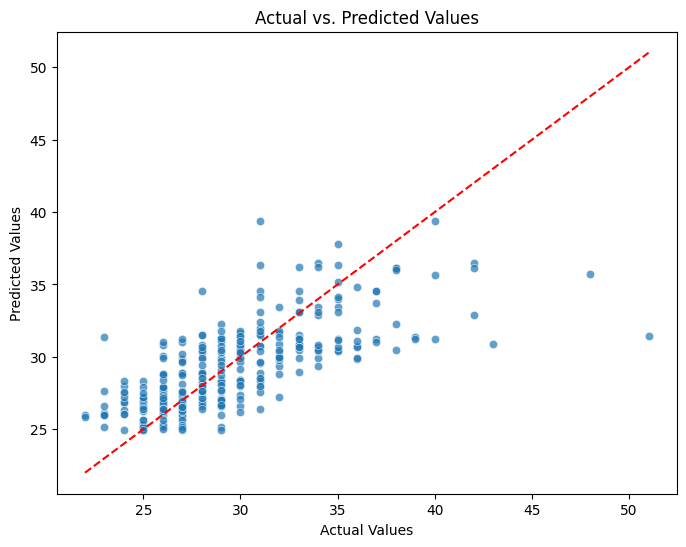

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot actual vs predicted values
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', linestyle='--') # Ideal predictions
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.show()

## Feature Importance Analysis

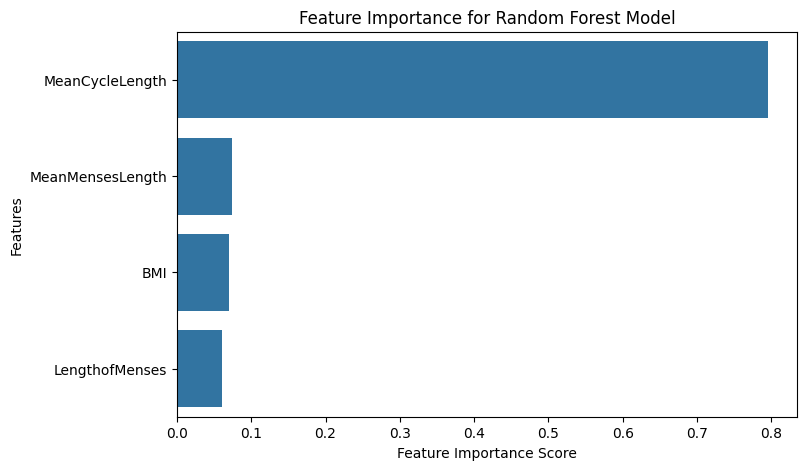

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance from the trained model
feature_importances = best_rf.feature_importances_

# Create a DataFrame
importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(8, 5))
sns.barplot(x=importance_df['Importance'], y=importance_df['Feature'])
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance for Random Forest Model")
plt.show()

## Save the Trained Model

In [14]:
import joblib

# Save the trained best RF model
joblib.dump(best_rf, "random_forest_model.pkl")

print("Model saved successfully as 'random_forest_model.pkl'!")

Model saved successfully as 'random_forest_model.pkl'!


## Verifying the Saved Model

In [15]:
# Load the saved model
loaded_rf_model = joblib.load("random_forest_model.pkl")

# Example: Make a prediction using the first row of X_test
sample_input = X_test.iloc[:1]  # Taking the first test example
prediction = loaded_rf_model.predict(sample_input)

print(f"Predicted LengthofCycle: {prediction[0]}")


Predicted LengthofCycle: 25.157008491508492
